> **Course notebook 5 of 5 - Capstone** | [Course home](../README.md) | [Previous: Positional Embeddings](04_positional_embeddings_demo.ipynb)
>
> **Recommended:** complete Notebooks 1-4 first. **Direct-entry option:** this notebook defines the essential terms below and can be studied independently at a slower pace. **Milestone:** trace every transformation from raw text to final input embeddings shaped [8, 4, 256].

# Complete LLM Data-Preprocessing Pipeline

This master notebook follows raw text all the way to the numerical input of a GPT-style Transformer. It is designed for inspection and experimentation. We stop **before** self-attention or any Transformer architecture.

## Quick start

This capstone connects the complete preprocessing path:

```text
text → token IDs → input/target windows → token embeddings
     → positional embeddings → Transformer-ready inputs
```

During training, an input token is paired with the token that follows it. A batch of token IDs has shape `[B, T]`; after embedding lookup it has shape `[B, T, D]`. Here, `B` is batch size, `T` is context length, and `D` is embedding dimension.

The notebook revisits earlier ideas with one continuous example. If a section feels unfamiliar, use its link to the focused notebook and return here afterward.

### Six phases

| Phase | Main question |
|---|---|
| A | How does text enter a finite vocabulary? |
| B | How do subwords handle unfamiliar text? |
| C | How do IDs become next-token examples? |
| D | How do IDs become trainable vectors? |
| E | How is token order added? |
| F | How do the pieces form the final tensor? |

## 0. Notebook roadmap

<pre>Raw text
   ↓
Tokenization
   ↓
Tokens
   ↓
Vocabulary / token IDs
   ↓
Input-target pairs
   ↓
Sliding windows
   ↓
Dataset
   ↓
DataLoader
   ↓
Batched IDs [B, T]
   ↓
Token embedding lookup
   ↓
Token embeddings [B, T, D]
          +
Position embeddings [T, D]
   ↓
Broadcasting
   ↓
Final input embeddings [B, T, D]
   ↓
Transformer — NOT implemented here</pre>

- <code>B</code> = batch size
- <code>T</code> = context length, or number of token positions
- <code>D</code> = embedding dimension

### Lecture reference values

| Quantity | Lecture value |
|---|---:|
| Raw-text characters | 20,479 |
| Word-token occurrences | 4,690 |
| Unique word-token vocabulary | 1,130 |
| Vocabulary after two special tokens | 1,132 |
| BPE-encoded lecture text | 5,145 tokens |
| GPT-2 vocabulary | 50,257 |
| Demonstration embedding dimension | 256 |
| Batch size | 8 |
| Context length | 4 |
| Input IDs | 8 × 4 |
| Token embeddings | 8 × 4 × 256 |
| Positional embeddings | 4 × 256 |
| Final input embeddings | 8 × 4 × 256 |

Our custom corpus will not reproduce the corpus-specific character, word-token, vocabulary, or BPE-token counts above. They are reference values from the lecture.

In [1]:
import math
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(123)
np.random.seed(123)
torch.set_printoptions(precision=4, sci_mode=False)

print("PyTorch:", torch.__version__)
print("Random seed: 123")

PyTorch: 2.9.1+cpu
Random seed: 123


# Phase A — Text to vocabulary

Build a transparent tokenizer, assign token IDs, and see why unknown and special tokens are needed.

## 1. Create raw text

The corpus below is custom, local, and deliberately includes repeated words, related word forms, and varied punctuation. Blank lines make the document boundaries visible.

In [2]:
raw_text = """
The small language-model laboratory opened early on Monday. A boy carried an old notebook, and two boys carried newer notebooks. "Can a model learn tokens?" he asked. Yes—it can learn token patterns, punctuation, and repeated words! The group wrote token, tokens, tokenizing, old, older, finest, and lowest on the board.

In a second document, a curious cat watched a dog beside the window. The dog chased the cat; the cat did not chase the dog. Order matters: dog bites man is not the same idea as man bites dog. The students paused, checked every comma, and tested every period.

Our custom corpus explains a practical pipeline. Raw text becomes tokens; tokens become IDs; IDs become sliding windows. Each input window has a target window shifted by one token. A Dataset stores examples, while a DataLoader groups examples into batches. Small batches make every shape easy to inspect.

Embeddings turn identifiers into trainable vectors. A token embedding answers what token is present, while a positional embedding marks where it occurs. The vectors begin as parameters, not as dictionaries of human-written meaning. Training can gradually change those parameters through next-token prediction loss.

The class repeats useful ideas for practice: token token tokens, model model models, boy boys, old older, finest lowest. Why repeat them? Repetition gives a tiny tokenizer and a tiny BPE demonstration something visible to count. Change this text, rerun the cells, and observe what changes—and what stays structurally the same!

A final paragraph makes the corpus long enough for many windows and full batches. We inspect input IDs, shifted target IDs, token vectors, position vectors, and final input embeddings. We verify claims with assertions, avoid giant matrix prints, and stop when the tensor is ready to enter the Transformer.
""".strip()

print("Number of characters:", len(raw_text))
print("\nFirst 300 characters:\n")
print(raw_text[:300])

Number of characters: 1837

First 300 characters:

The small language-model laboratory opened early on Monday. A boy carried an old notebook, and two boys carried newer notebooks. "Can a model learn tokens?" he asked. Yes—it can learn token patterns, punctuation, and repeated words! The group wrote token, tokens, tokenizing, old, older, finest, and 


**What the output means**

- A **character** is one text symbol, including spaces and punctuation.
- A **word** is a human linguistic concept, but software needs rules to locate it.
- A **token** is one unit produced by a particular tokenizer. A token may be a word, punctuation mark, character, or subword.

**Check:** the printed character count includes spaces and line breaks.

**Try it:** add one exclamation mark to <code>raw_text</code>. Predict how <code>len(raw_text)</code> changes.

## 2. Naive whitespace tokenization

We start deliberately with an inadequate rule so its weakness is obvious.

In [3]:
sample_text = "Hello, world. This is a test!"
naive_parts = re.split(r"(\s)", sample_text)

print("Raw split pieces:", naive_parts)
print("\nNon-whitespace pieces:", [item for item in naive_parts if item.strip()])
print("\nWhitespace pieces:", [repr(item) for item in naive_parts if not item.strip()])

Raw split pieces: ['Hello,', ' ', 'world.', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test!']

Non-whitespace pieces: ['Hello,', 'world.', 'This', 'is', 'a', 'test!']

Whitespace pieces: ["' '", "' '", "' '", "' '", "' '"]


<code>Hello,</code>, <code>world.</code>, and <code>test!</code> keep punctuation attached. A space-only split also exposes whitespace pieces when we capture the separator. This is not enough when we want punctuation to be visible as its own token.

**Check:** assert that the comma is still attached to <code>Hello</code>.

**Try it:** replace the comma with a semicolon and rerun.

In [4]:
assert "Hello," in naive_parts
print("Check passed: punctuation is still attached in the naive split.")

Check passed: punctuation is still attached in the naive split.


## 3. Separate punctuation

This educational regular expression captures whitespace and common punctuation so each separator remains visible in the result.

In [5]:
TOKEN_PATTERN = r"([,.:;?!\"'()\-—_]|\s+)"

punctuation_sample = "Hello, world! (Tokenizing-old_text: isn't magic.)"
separated_parts = re.split(TOKEN_PATTERN, punctuation_sample)
separated_tokens = [item for item in separated_parts if item and item.strip()]

print("Input:", punctuation_sample)
print("\nindex → token")
for index, token in enumerate(separated_tokens):
    print(f"{index:>2} → {token!r}")

assert separated_tokens[:4] == ["Hello", ",", "world", "!"]

Input: Hello, world! (Tokenizing-old_text: isn't magic.)

index → token
 0 → 'Hello'
 1 → ','
 2 → 'world'
 3 → '!'
 4 → '('
 5 → 'Tokenizing'
 6 → '-'
 7 → 'old'
 8 → '_'
 9 → 'text'
10 → ':'
11 → 'isn'
12 → "'"
13 → 't'
14 → 'magic'
15 → '.'
16 → ')'


Punctuation now has its own entries. This is an **educational simplification**: production tokenizers use more detailed rules and often preserve whitespace information differently.

**Try it:** add brackets or a slash to the sample. Does the current pattern split them?

## 4. Remove whitespace tokens

<code>item.strip()</code> removes surrounding whitespace. For a piece containing only spaces or a newline, it becomes an empty string, and <code>bool("")</code> is <code>False</code>.

In [6]:
before_filtering = re.split(TOKEN_PATTERN, "Hello,   world!\nNext line.")
after_filtering = [item for item in before_filtering if item and item.strip()]

print("BEFORE filtering:")
for item in before_filtering:
    print(f"{item!r:14} strip={item.strip()!r:10} bool(strip)={bool(item.strip())}")

print("\nAFTER filtering:", after_filtering)
assert all(item.strip() for item in after_filtering)

BEFORE filtering:
'Hello'        strip='Hello'    bool(strip)=True
','            strip=','        bool(strip)=True
''             strip=''         bool(strip)=False
'   '          strip=''         bool(strip)=False
'world'        strip='world'    bool(strip)=True
'!'            strip='!'        bool(strip)=True
''             strip=''         bool(strip)=False
'\n'           strip=''         bool(strip)=False
'Next'         strip='Next'     bool(strip)=True
' '            strip=''         bool(strip)=False
'line'         strip='line'     bool(strip)=True
'.'            strip='.'        bool(strip)=True
''             strip=''         bool(strip)=False

AFTER filtering: ['Hello', ',', 'world', '!', 'Next', 'line', '.']


> **Important simplification:** whitespace is being removed for this educational tokenizer, but whitespace can itself contain useful information—especially in code, where indentation matters.

**Try it:** use a tab character and inspect <code>repr(item)</code> before filtering.

## 5. Tokenize the complete custom corpus

We now apply the same visible regex logic to every character in <code>raw_text</code>.

In [7]:
raw_parts = re.split(TOKEN_PATTERN, raw_text)
preprocessed = [item for item in raw_parts if item and item.strip()]

print("First 30 tokens:")
print(preprocessed[:30])
print("\nTOTAL TOKEN OCCURRENCES:", len(preprocessed))
print("UNIQUE TOKENS:", len(set(preprocessed)))

punctuation_found = [token for token in preprocessed if re.fullmatch(r"[,.:;?!\"'()\-—_]", token)]
print("\nFirst 20 punctuation tokens:", punctuation_found[:20])

counts = Counter(preprocessed)
print("Repeated-token counts:")
for token in ["token", "tokens", "model", "boy", "old"]:
    print(f"  {token!r}: {counts[token]}")

First 30 tokens:
['The', 'small', 'language', '-', 'model', 'laboratory', 'opened', 'early', 'on', 'Monday', '.', 'A', 'boy', 'carried', 'an', 'old', 'notebook', ',', 'and', 'two', 'boys', 'carried', 'newer', 'notebooks', '.', '"', 'Can', 'a', 'model', 'learn']

TOTAL TOKEN OCCURRENCES: 360
UNIQUE TOKENS: 192

First 20 punctuation tokens: ['-', '.', ',', '.', '"', '?', '"', '.', '—', ',', ',', '!', ',', ',', ',', ',', ',', ',', '.', ',']
Repeated-token counts:
  'token': 9
  'tokens': 5
  'model': 4
  'boy': 2
  'old': 3


<pre>["cat", "sat", "cat"]
3 token occurrences
2 unique tokens</pre>

An occurrence counts every appearance. A unique-token count removes duplicates.

**Check:** total occurrences must be at least the number of unique tokens.

**Try it:** repeat <code>cat</code> three more times. Which count changes, and by how much?

In [8]:
assert len(preprocessed) >= len(set(preprocessed))
assert counts["token"] > 1
print("Checks passed: occurrence count ≥ unique count, and 'token' repeats.")

Checks passed: occurrence count ≥ unique count, and 'token' repeats.


## 6. Build the vocabulary

A vocabulary maps each unique token to one unique integer. We remove duplicates, sort for reproducible ordering, then enumerate.

In [9]:
all_tokens = sorted(set(preprocessed))
str_to_int = {token: token_id for token_id, token in enumerate(all_tokens)}

print("Vocabulary size:", len(str_to_int))
print("\nFirst 20 entries:")
for token, token_id in list(str_to_int.items())[:20]:
    print(f"{token!r:18} → {token_id}")

print("\nLast 10 entries:")
for token, token_id in list(str_to_int.items())[-10:]:
    print(f"{token!r:18} → {token_id}")

Vocabulary size: 192

First 20 entries:
'!'                → 0
'"'                → 1
','                → 2
'-'                → 3
'.'                → 4
':'                → 5
';'                → 6
'?'                → 7
'A'                → 8
'BPE'              → 9
'Can'              → 10
'Change'           → 11
'DataLoader'       → 12
'Dataset'          → 13
'Each'             → 14
'Embeddings'       → 15
'IDs'              → 16
'In'               → 17
'Monday'           → 18
'Order'            → 19

Last 10 entries:
'when'             → 182
'where'            → 183
'while'            → 184
'window'           → 185
'windows'          → 186
'with'             → 187
'words'            → 188
'written'          → 189
'wrote'            → 190
'—'                → 191


A token ID is an **identifier**, not a measurement. If <code>cat = 50</code> and <code>dog = 700</code>, the larger number does not make dog larger, more meaningful, or less related to cat.

**Check:** IDs are unique and cover <code>0</code> through <code>vocabulary_size − 1</code>.

**Try it:** remove <code>sorted</code>. Would the mapping still work? Would its ID ordering be as easy to reproduce?

In [10]:
assert len(set(str_to_int.values())) == len(str_to_int)
assert set(str_to_int.values()) == set(range(len(str_to_int)))
print("Vocabulary checks passed.")

Vocabulary checks passed.


## 7. Reverse vocabulary

Decoding needs the inverse lookup: token ID → token.

In [11]:
int_to_str = {token_id: token for token, token_id in str_to_int.items()}

for token in ["boy", "tokens", "older", "!"]:
    token_id = str_to_int[token]
    reconstructed = int_to_str[token_id]
    print(f"{token!r} → {token_id} → {reconstructed!r}")
    assert reconstructed == token

assert all(int_to_str[token_id] == token for token, token_id in str_to_int.items())
print("\nAll token → ID → token round trips passed.")

'boy' → 45 → 'boy'
'tokens' → 172 → 'tokens'
'older' → 123 → 'older'
'!' → 0 → '!'

All token → ID → token round trips passed.


**Try it:** choose any token printed in Section 5 and perform its round trip manually before asking Python.

## 8. SimpleTokenizerV1

This small class packages the same visible steps. <code>encode</code> maps text to IDs; <code>decode</code> maps IDs back to readable text and removes unnecessary spaces before punctuation.

In [12]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {token_id: token for token, token_id in vocab.items()}

    def encode(self, text):
        pieces = re.split(TOKEN_PATTERN, text)
        tokens = [item for item in pieces if item and item.strip()]
        return [self.str_to_int[token] for token in tokens]

    def decode(self, token_ids):
        tokens = [self.int_to_str[token_id] for token_id in token_ids]
        text = " ".join(tokens)
        text = re.sub(r"\s+([,.:;?!\"')\-—_])", r"\1", text)
        text = re.sub(r"\(\s+", "(", text)
        return text


tokenizer_v1 = SimpleTokenizerV1(str_to_int)

In [13]:
v1_text = "The boy carried an old notebook, and two boys carried newer notebooks."
v1_ids = tokenizer_v1.encode(v1_text)
v1_decoded = tokenizer_v1.decode(v1_ids)

print("Original text:\n", v1_text)
print("\nEncoded IDs:\n", v1_ids)
print("\nDecoded text:\n", v1_decoded)

assert v1_decoded == v1_text
print("\nExact round-trip check passed.")

Original text:
 The boy carried an old notebook, and two boys carried newer notebooks.

Encoded IDs:
 [24, 45, 49, 31, 122, 117, 2, 32, 175, 46, 49, 114, 118, 4]

Decoded text:
 The boy carried an old notebook, and two boys carried newer notebooks.

Exact round-trip check passed.


The IDs carry enough information to select vocabulary entries and reconstruct this known sentence. The spacing repair is intentionally small and is not a complete natural-language detokenizer.

**Try it:** encode another sentence made only from tokens present in <code>raw_text</code>.

## 9. Force an out-of-vocabulary error

**OOV** means **Out Of Vocabulary**. V1 performs direct dictionary lookup, so a new token has no ID.

In [14]:
oov_text = "The hyperbananaquantum appeared."

try:
    tokenizer_v1.encode(oov_text)
except KeyError as error:
    print("Unknown token:", error)
    print("This failed because the token was not present in the vocabulary.")
else:
    raise AssertionError("The demonstration word unexpectedly existed in the vocabulary.")

Unknown token: 'hyperbananaquantum'
This failed because the token was not present in the vocabulary.


A basic fixed word vocabulary cannot represent a genuinely new word. We caught the error so the notebook remains runnable.

**Try it:** replace the invented word with another word that is absent from the corpus.

## 10. Special tokens

We add two entries after the ordinary vocabulary:

- <code>&lt;|unk|&gt;</code> represents an unrecognized token.
- <code>&lt;|endoftext|&gt;</code> marks a boundary between unrelated documents.

In [15]:
old_vocab_size = len(str_to_int)
vocab_with_special = dict(str_to_int)
vocab_with_special["<|unk|>"] = len(vocab_with_special)
vocab_with_special["<|endoftext|>"] = len(vocab_with_special)
new_vocab_size = len(vocab_with_special)

print("Old vocabulary size:", old_vocab_size)
print("New vocabulary size:", new_vocab_size)
print("<|unk|> ID:", vocab_with_special["<|unk|>"])
print("<|endoftext|> ID:", vocab_with_special["<|endoftext|>"])

assert new_vocab_size == old_vocab_size + 2

Old vocabulary size: 192
New vocabulary size: 194
<|unk|> ID: 192
<|endoftext|> ID: 193


Other systems may also define beginning-of-sequence, end-of-sequence, or padding tokens. We do not need to implement those here.

**Try it:** predict the next ID that would be assigned if a padding token were appended.

## 11. SimpleTokenizerV2

V2 substitutes <code>&lt;|unk|&gt;</code> instead of failing. The end-of-text marker remains a visible token between documents.

In [16]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {token_id: token for token, token_id in vocab.items()}

    def encode(self, text):
        pieces = re.split(TOKEN_PATTERN, text)
        tokens = [item for item in pieces if item and item.strip()]
        unk_id = self.str_to_int["<|unk|>"]
        return [self.str_to_int.get(token, unk_id) for token in tokens]

    def decode(self, token_ids):
        tokens = [self.int_to_str[token_id] for token_id in token_ids]
        text = " ".join(tokens)
        text = re.sub(r"\s+([,.:;?!\"')\-—_])", r"\1", text)
        text = re.sub(r"\(\s+", "(", text)
        return text


tokenizer_v2 = SimpleTokenizerV2(vocab_with_special)

In [17]:
document_1 = "The boy carried a hyperbananaquantum."
document_2 = "A mysterious ultrakiwi arrived!"
combined_documents = document_1 + " <|endoftext|> " + document_2

v2_ids = tokenizer_v2.encode(combined_documents)
v2_decoded = tokenizer_v2.decode(v2_ids)

print("Combined documents:\n", combined_documents)
print("\nEncoded IDs:\n", v2_ids)
print("\nDecoded text:\n", v2_decoded)
print("\nUnknown ID appears:", vocab_with_special["<|unk|>"] in v2_ids)
print("End-of-text ID appears:", vocab_with_special["<|endoftext|>"] in v2_ids)

assert vocab_with_special["<|unk|>"] in v2_ids
assert vocab_with_special["<|endoftext|>"] in v2_ids

Combined documents:
 The boy carried a hyperbananaquantum. <|endoftext|> A mysterious ultrakiwi arrived!

Encoded IDs:
 [24, 45, 49, 30, 192, 4, 193, 8, 192, 192, 192, 0]

Decoded text:
 The boy carried a <|unk|>. <|endoftext|> A <|unk|> <|unk|> <|unk|>!

Unknown ID appears: True
End-of-text ID appears: True


Unknown words survive only as the generic unknown marker, so their spelling is lost. The document boundary remains explicit.

**Try it:** place two different invented words in the input. Notice that both map to the same unknown ID.

# Phase B — Words to reusable subwords

Compare tokenization levels, observe BPE merges, and use GPT-2's byte-level tokenizer.

## 12. Word vs. character tokenization

We apply two tokenization ideas to the **same** sentence. The word-level version uses the educational regex; the character-level version keeps every non-whitespace character.

In [18]:
comparison_text = "hobby helps a hobby!"
word_level_tokens = [
    item for item in re.split(TOKEN_PATTERN, comparison_text)
    if item and item.strip()
]
character_level_tokens = [character for character in comparison_text if not character.isspace()]

print("Identical input:", comparison_text)
print("\nWORD-LEVEL TOKENS:", word_level_tokens)
print("Number of tokens:", len(word_level_tokens))
print("Constructed vocabulary size:", len(set(word_level_tokens)))

print("\nCHARACTER-LEVEL TOKENS:", character_level_tokens)
print("Number of tokens:", len(character_level_tokens))
print("Constructed vocabulary size:", len(set(character_level_tokens)))

print("\n'hobby' as a word token:", ["hobby"])
print("'hobby' as characters:", list("hobby"))

Identical input: hobby helps a hobby!

WORD-LEVEL TOKENS: ['hobby', 'helps', 'a', 'hobby', '!']
Number of tokens: 5
Constructed vocabulary size: 4

CHARACTER-LEVEL TOKENS: ['h', 'o', 'b', 'b', 'y', 'h', 'e', 'l', 'p', 's', 'a', 'h', 'o', 'b', 'b', 'y', '!']
Number of tokens: 17
Constructed vocabulary size: 10

'hobby' as a word token: ['hobby']
'hobby' as characters: ['h', 'o', 'b', 'b', 'y']


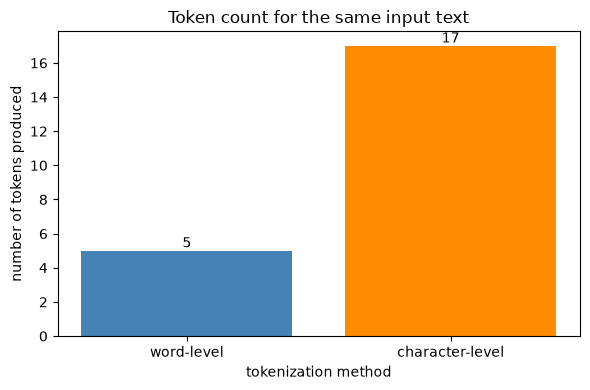

In [19]:
token_counts = [len(word_level_tokens), len(character_level_tokens)]
plt.figure(figsize=(6, 4))
plt.bar(["word-level", "character-level"], token_counts, color=["steelblue", "darkorange"])
plt.ylabel("number of tokens produced")
plt.xlabel("tokenization method")
plt.title("Token count for the same input text")
for index, count in enumerate(token_counts):
    plt.text(index, count + 0.2, str(count), ha="center")
plt.tight_layout()
plt.show()

| Word level | Character level |
|---|---|
| Usually fewer sequence tokens | Usually much longer sequences |
| Potentially enormous vocabulary | Much smaller vocabulary |
| Has an OOV problem | Can construct arbitrary words |
| Related forms such as <code>boy</code>/<code>boys</code> may be separate entries | Loses useful larger word/subword units |

The vocabulary sizes printed here belong only to this tiny sentence; they are not general vocabulary sizes.

**Try it:** replace <code>hobby</code> with a longer word and predict which bar grows more.

## 13. Why subword tokenization?

Subword tokenization lies between whole words and individual characters.

<pre>boy       → ["boy"]
boys      → ["boy", "s"]

token     → ["token"]
tokens    → ["token", "s"]
tokenizing→ ["token", "izing"]</pre>

These are conceptual examples, not guaranteed outputs from every trained tokenizer. A subword vocabulary may contain whole words, recurring subwords, or very small pieces depending on what was learned.

> Reusing a subword does not make its **token ID** semantic. Tokenization pieces and learned embedding meaning are separate concepts.

**Try it:** propose reusable pieces for <code>old</code>, <code>older</code>, and <code>oldest</code>.

## 14. Tiny BPE demonstration from scratch

This is an **educational BPE-style merge demonstration**. Each word begins as characters plus <code>&lt;/w&gt;</code>, a visible end-of-word marker. Adjacent-pair counts are weighted by word frequency. The most frequent pair is calculated and merged—never hard-coded.

In [20]:
word_frequencies = {
    "old": 7,
    "older": 3,
    "finest": 9,
    "lowest": 4,
}

initial_bpe_vocab = {
    tuple(list(word) + ["</w>"]): frequency
    for word, frequency in word_frequencies.items()
}


def count_adjacent_pairs(vocabulary):
    pair_counts = Counter()
    for symbols, frequency in vocabulary.items():
        for left, right in zip(symbols, symbols[1:]):
            pair_counts[(left, right)] += frequency
    return pair_counts


def merge_adjacent_pair(pair, vocabulary):
    merged_vocabulary = {}
    merged_symbol = "".join(pair)

    for symbols, frequency in vocabulary.items():
        new_symbols = []
        index = 0
        while index < len(symbols):
            if index < len(symbols) - 1 and (symbols[index], symbols[index + 1]) == pair:
                new_symbols.append(merged_symbol)
                index += 2
            else:
                new_symbols.append(symbols[index])
                index += 1
        merged_vocabulary[tuple(new_symbols)] = frequency

    return merged_vocabulary


def print_bpe_vocabulary(vocabulary):
    for symbols, frequency in vocabulary.items():
        print(f"  {' '.join(symbols):28} frequency={frequency}")

In [21]:
num_merges = 5
bpe_vocabulary = dict(initial_bpe_vocab)
merge_history = []

for iteration in range(1, num_merges + 1):
    pair_counts = count_adjacent_pairs(bpe_vocabulary)
    most_frequent_pair, frequency = max(
        pair_counts.items(),
        key=lambda item: (item[1], item[0]),
    )

    print(f"\n{'=' * 58}")
    print(f"Iteration {iteration}")
    print("Most frequent pair:", most_frequent_pair)
    print("Frequency:", frequency)
    print("\nVocabulary BEFORE:")
    print_bpe_vocabulary(bpe_vocabulary)

    next_vocabulary = merge_adjacent_pair(most_frequent_pair, bpe_vocabulary)
    print("\nVocabulary AFTER:")
    print_bpe_vocabulary(next_vocabulary)

    merge_history.append({
        "iteration": iteration,
        "pair": most_frequent_pair,
        "frequency": frequency,
    })
    bpe_vocabulary = next_vocabulary


Iteration 1
Most frequent pair: ('t', '</w>')
Frequency: 13

Vocabulary BEFORE:
  o l d </w>                   frequency=7
  o l d e r </w>               frequency=3
  f i n e s t </w>             frequency=9
  l o w e s t </w>             frequency=4

Vocabulary AFTER:
  o l d </w>                   frequency=7
  o l d e r </w>               frequency=3
  f i n e s t</w>              frequency=9
  l o w e s t</w>              frequency=4

Iteration 2
Most frequent pair: ('s', 't</w>')
Frequency: 13

Vocabulary BEFORE:
  o l d </w>                   frequency=7
  o l d e r </w>               frequency=3
  f i n e s t</w>              frequency=9
  l o w e s t</w>              frequency=4

Vocabulary AFTER:
  o l d </w>                   frequency=7
  o l d e r </w>               frequency=3
  f i n e st</w>               frequency=9
  l o w e st</w>               frequency=4

Iteration 3
Most frequent pair: ('e', 'st</w>')
Frequency: 13

Vocabulary BEFORE:
  o l d </w>                

Recurring adjacent pieces become one larger reusable unit. For example, the frequency-weighted calculation can discover <code>e + s → es</code>, then build larger pieces in later iterations.

**Check:** every recorded merge came from the highest current pair count.

**Try it:** change <code>finest</code>'s frequency from 9 to 1. Which early merge changes?

In [22]:
assert len(merge_history) == num_merges
assert all(item["frequency"] > 0 for item in merge_history)
print("BPE merge-history checks passed.")

BPE merge-history checks passed.


## 15. BPE stop condition

Our loop ran **exactly** <code>num_merges = 5</code> iterations and then stopped. BPE does not merge forever: tokenizer training uses a chosen merge budget or target vocabulary size.

<pre>more merges → larger learned token vocabulary → potentially shorter encodings
fewer merges → smaller learned token vocabulary → potentially longer encodings</pre>

“Potentially” matters: the effect depends on the text and learned pieces.

**Try it:** set <code>num_merges</code> to 2 or 8, rerun Sections 14–16, and compare the final pieces.

In [23]:
print("Requested merge count:", num_merges)
print("Completed merge count:", len(merge_history))
assert len(merge_history) == 5

Requested merge count: 5
Completed merge count: 5


## 16. Visualize BPE

The chart records the winning pair frequency at each merge. The printed sets compare starting pieces with pieces present after five merges.

Initial pieces:
['</w>', 'd', 'e', 'f', 'i', 'l', 'n', 'o', 'r', 's', 't', 'w']

Pieces after merges:
['</w>', 'e', 'est</w>', 'f', 'i', 'l', 'n', 'o', 'old', 'r', 'w']

Merge table:
iteration 1: t + </w>         frequency=13
iteration 2: s + t</w>        frequency=13
iteration 3: e + st</w>       frequency=13
iteration 4: o + l            frequency=10
iteration 5: ol + d           frequency=10


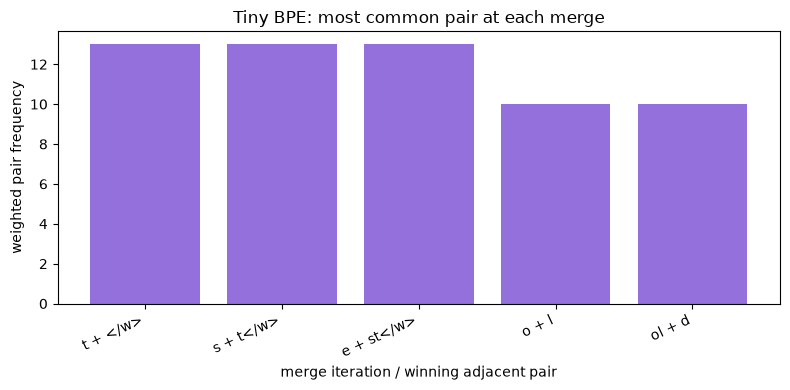

In [24]:
initial_pieces = sorted({piece for symbols in initial_bpe_vocab for piece in symbols})
learned_pieces = sorted({piece for symbols in bpe_vocabulary for piece in symbols})

print("Initial pieces:")
print(initial_pieces)
print("\nPieces after merges:")
print(learned_pieces)
print("\nMerge table:")
for item in merge_history:
    pair_text = " + ".join(item["pair"])
    print(f"iteration {item['iteration']}: {pair_text:16} frequency={item['frequency']}")

labels = [" + ".join(item["pair"]) for item in merge_history]
frequencies = [item["frequency"] for item in merge_history]
plt.figure(figsize=(8, 4))
plt.bar(range(1, num_merges + 1), frequencies, color="mediumpurple")
plt.xticks(range(1, num_merges + 1), labels, rotation=25, ha="right")
plt.xlabel("merge iteration / winning adjacent pair")
plt.ylabel("weighted pair frequency")
plt.title("Tiny BPE: most common pair at each merge")
plt.tight_layout()
plt.show()

A later merged piece can contain a piece learned earlier. That is how recurring local patterns grow into larger units.

**Try it:** inspect which learned pieces appear in more than one final word.

## 17. Real GPT-style tokenization with tiktoken

From here we introduce the GPT-2 BPE tokenizer. The cell installs <code>tiktoken</code> only if this notebook kernel cannot import it.

In [25]:
try:
    import tiktoken
except ImportError:
    print("tiktoken is missing; installing it into this notebook kernel...")
    get_ipython().run_line_magic("pip", "install tiktoken")
    import tiktoken

print("tiktoken imported successfully.")

tiktoken imported successfully.


In [26]:
tokenizer = tiktoken.get_encoding("gpt2")
gpt2_text = "A tokenizer converts text into token IDs—and back again!"
gpt2_ids = tokenizer.encode(gpt2_text)
gpt2_decoded = tokenizer.decode(gpt2_ids)

print("GPT-2 vocabulary size:", tokenizer.n_vocab)
print("Text:", gpt2_text)
print("Token IDs:", gpt2_ids)
print("Decoded text:", gpt2_decoded)
print("Exact round trip?", gpt2_decoded == gpt2_text)

assert tokenizer.n_vocab == 50_257
assert gpt2_decoded == gpt2_text

GPT-2 vocabulary size: 50257
Text: A tokenizer converts text into token IDs—and back again!
Token IDs: [32, 11241, 7509, 26161, 2420, 656, 11241, 32373, 960, 392, 736, 757, 0]
Decoded text: A tokenizer converts text into token IDs—and back again!
Exact round trip? True


The production tokenizer has a much larger learned vocabulary than our homemade word tokenizer and preserves the exact input in this round trip.

**Try it:** change punctuation or add multiple spaces. Check whether the exact round trip still succeeds.

## 18. Inspect actual BPE token pieces

An unusual word does not require a generic unknown marker. GPT-2 BPE can represent it using known smaller byte-level pieces.

In [27]:
unusual_text = "Tokenizing hyperbananaquantum is interesting!"
unusual_ids = tokenizer.encode(unusual_text)

print("Text:", unusual_text)
print("\ntoken ID → decoded byte/token piece")
for token_id in unusual_ids:
    piece_bytes = tokenizer.decode_single_token_bytes(token_id)
    safe_piece = piece_bytes.decode("utf-8", errors="replace")
    print(f"{token_id:>6} → bytes={piece_bytes!r:18} display={safe_piece!r}")

assert tokenizer.decode(unusual_ids) == unusual_text

Text: Tokenizing hyperbananaquantum is interesting!

token ID → decoded byte/token piece
 30642 → bytes=b'Token'           display='Token'
  2890 → bytes=b'izing'           display='izing'
  8718 → bytes=b' hyper'          display=' hyper'
  3820 → bytes=b'ban'             display='ban'
  2271 → bytes=b'ana'             display='ana'
 40972 → bytes=b'quant'           display='quant'
   388 → bytes=b'um'              display='um'
   318 → bytes=b' is'             display=' is'
  3499 → bytes=b' interesting'    display=' interesting'
     0 → bytes=b'!'               display='!'


The invented word is split into pieces already known to the tokenizer. Byte-level fallback makes arbitrary text representable without our word-level <code>&lt;|unk|&gt;</code> behavior.

**Try it:** invent an even stranger word and count how many pieces it produces.

## 19. GPT-style end-of-text token

GPT-2's <code>&lt;|endoftext|&gt;</code> is a special token. Encoding it requires explicitly allowing that special value.

In [28]:
gpt2_eot_text = "<|endoftext|>"
gpt2_eot_id = tokenizer.encode(
    gpt2_eot_text,
    allowed_special={gpt2_eot_text},
)[0]

gpt2_document_1 = "The first local document ends here."
gpt2_document_2 = "A separate document begins here."
gpt2_combined = gpt2_document_1 + gpt2_eot_text + gpt2_document_2
gpt2_combined_ids = tokenizer.encode(
    gpt2_combined,
    allowed_special={gpt2_eot_text},
)
eot_positions = [index for index, token_id in enumerate(gpt2_combined_ids) if token_id == gpt2_eot_id]

print("<|endoftext|> token ID:", gpt2_eot_id)
print("Special-token position(s):", eot_positions)
print("Decoded combined text:", tokenizer.decode(gpt2_combined_ids))

assert gpt2_eot_id == 50_256
assert len(eot_positions) == 1

<|endoftext|> token ID: 50256
Special-token position(s): [7]
Decoded combined text: The first local document ends here.<|endoftext|>A separate document begins here.


The special token marks a boundary between documents that should not be treated as one continuous passage.

**Try it:** insert two end-of-text markers and predict the number of positions found.

## 20. Compare available tiktoken encodings

Tokenizer vocabularies can differ. We print only encoding names and vocabulary sizes; we make no claim here about any particular modern model's internal tokenizer.

In [29]:
available_encoding_names = tiktoken.list_encoding_names()
assert "gpt2" in available_encoding_names
assert "cl100k_base" in available_encoding_names

# GPT-2 is instantiated above. We use the registered cl100k_base reference size
# without constructing it, because first construction may fetch uncached data.
encoding_sizes = {
    "gpt2": tokenizer.n_vocab,
    "cl100k_base": 100_277,
}

print("encoding name → vocabulary size")
print(f"{'gpt2':12} → {encoding_sizes['gpt2']:,} (loaded locally)")
print(f"{'cl100k_base':12} → {encoding_sizes['cl100k_base']:,} (registered encoding; reference size)")
print("No tokenizer data was downloaded for this comparison.")

assert encoding_sizes["gpt2"] != encoding_sizes["cl100k_base"]

encoding name → vocabulary size
gpt2         → 50,257 (loaded locally)
cl100k_base  → 100,277 (registered encoding; reference size)
No tokenizer data was downloaded for this comparison.


Different learned vocabularies can segment identical text differently.

**Try it:** encode the invented word with both encodings and compare token counts.

# Phase C — IDs to training examples

Shift the token stream into next-token input-target pairs, then organize them with sliding windows and batches.

## 21. From text to one long token-ID stream

For the main training pipeline, we now stop using the homemade tokenizer and use GPT-2 <code>tiktoken</code>.

In [30]:
token_ids = tokenizer.encode(raw_text)

print("Total BPE tokens:", len(token_ids))
print("First 20 token IDs:")
print(token_ids[:20])
print("\nDecoded first 20 IDs:")
print(repr(tokenizer.decode(token_ids[:20])))

assert len(token_ids) > 8 * 4 + 1

Total BPE tokens: 389
First 20 token IDs:
[464, 1402, 3303, 12, 19849, 14010, 4721, 1903, 319, 3321, 13, 317, 2933, 5281, 281, 1468, 20922, 11, 290, 734]

Decoded first 20 IDs:
'The small language-model laboratory opened early on Monday. A boy carried an old notebook, and two'


The document is now essentially one long sequence:

<pre>[t0, t1, t2, t3, ...]</pre>

The next stages create many shorter training examples from this stream.

**Try it:** compare the character count from Section 1 with this BPE-token count. They measure different units.

## 22. Next-token prediction intuition

GPT predicts **one next token** at each position—not necessarily one whole word. A context can grow one token at a time.

In [31]:
prediction_text = "The model learns to predict the next token."
prediction_ids = tokenizer.encode(prediction_text)

print("Text:", prediction_text)
print("Token IDs:", prediction_ids)
print("\ncontext available → one target token")
for target_position in range(1, len(prediction_ids)):
    available_context = tokenizer.decode(prediction_ids[:target_position])
    target_token = tokenizer.decode([prediction_ids[target_position]])
    print(f"{available_context!r:42} → {target_token!r}")

Text: The model learns to predict the next token.
Token IDs: [464, 2746, 22974, 284, 4331, 262, 1306, 11241, 13]

context available → one target token
'The'                                      → ' model'
'The model'                                → ' learns'
'The model learns'                         → ' to'
'The model learns to'                      → ' predict'
'The model learns to predict'              → ' the'
'The model learns to predict the'          → ' next'
'The model learns to predict the next'     → ' token'
'The model learns to predict the next token' → '.'


Each row is one prediction situation. A displayed token can contain a leading space, punctuation, a subword, or a whole word.

**Try it:** inspect which targets are punctuation tokens.

## 23. One sequence contains multiple prediction tasks

Five consecutive stream tokens create a four-token input <code>X</code> and four shifted targets <code>Y</code>.

In [32]:
context_length = 4
five_ids = token_ids[: context_length + 1]
X = five_ids[:-1]
Y = five_ids[1:]

print("Five consecutive IDs:", five_ids)
print("X token IDs:", X)
print("Y token IDs:", Y)

for position in range(context_length):
    context_available = tokenizer.decode(X[: position + 1])
    target_piece = tokenizer.decode([Y[position]])
    print(f"\nposition {position}:")
    print("  context available →", repr(context_available))
    print("  target token      →", repr(target_piece), f"(ID {Y[position]})")

assert len(X) == len(Y) == context_length

Five consecutive IDs: [464, 1402, 3303, 12, 19849]
X token IDs: [464, 1402, 3303, 12]
Y token IDs: [1402, 3303, 12, 19849]

position 0:
  context available → 'The'
  target token      → ' small' (ID 1402)

position 1:
  context available → 'The small'
  target token      → ' language' (ID 3303)

position 2:
  context available → 'The small language'
  target token      → '-' (ID 12)

position 3:
  context available → 'The small language-'
  target token      → 'model' (ID 19849)


One length-4 training sequence supplies four next-token targets. Later, a causal Transformer would restrict each position to appropriate earlier context; we do not implement that model here.

**Try it:** change <code>context_length</code> conceptually to 8. How many target positions would one sequence contain?

## 24. Input and target are shifted

The target begins one token later than the input so each input position is paired with the token that follows it.

In [33]:
i = 10
input_chunk = token_ids[i : i + context_length]
target_chunk = token_ids[i + 1 : i + context_length + 1]

print("Input chunk IDs: ", input_chunk)
print("Target chunk IDs:", target_chunk)
print("Input text: ", repr(tokenizer.decode(input_chunk)))
print("Target text:", repr(tokenizer.decode(target_chunk)))

assert input_chunk[1:] == target_chunk[:-1]
print("\nShift check passed: input_chunk[1:] == target_chunk[:-1]")

Input chunk IDs:  [13, 317, 2933, 5281]
Target chunk IDs: [317, 2933, 5281, 281]
Input text:  '. A boy carried'
Target text: ' A boy carried an'

Shift check passed: input_chunk[1:] == target_chunk[:-1]


The target at index <code>k</code> is the token immediately after the input at index <code>k</code> in the original stream.

**Try it:** change <code>i</code> and confirm that the relationship still holds.

## 25. Sliding windows

<code>context_length</code> is the width of each window. <code>stride</code> is how far its starting position moves.

In [34]:
visible_sequence = list(range(12))
visible_context_length = 4

for visible_stride in [1, 4]:
    print(f"\ncontext_length=4, stride={visible_stride}")
    for start in range(0, len(visible_sequence) - visible_context_length + 1, visible_stride):
        indentation = "  " * start
        window = visible_sequence[start : start + visible_context_length]
        print(f"{indentation}{window}")


context_length=4, stride=1
[0, 1, 2, 3]
  [1, 2, 3, 4]
    [2, 3, 4, 5]
      [3, 4, 5, 6]
        [4, 5, 6, 7]
          [5, 6, 7, 8]
            [6, 7, 8, 9]
              [7, 8, 9, 10]
                [8, 9, 10, 11]

context_length=4, stride=4
[0, 1, 2, 3]
        [4, 5, 6, 7]
                [8, 9, 10, 11]


Stride 1 creates heavily overlapping examples. Stride 4 creates adjacent non-overlapping input windows here. Neither setting changes the width.

**Try it:** predict the start positions for stride 2.

## 26. Visualize stride

Each colored row below is one length-4 window. Columns are token positions. More rows mean more overlap and more training examples.

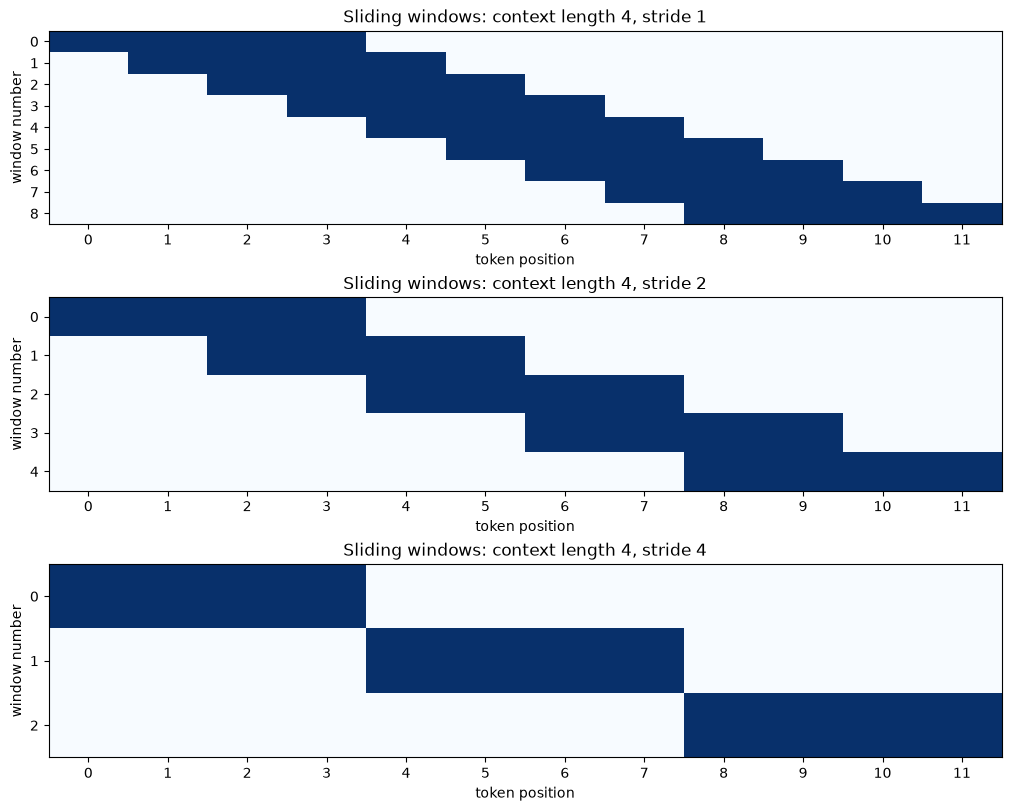

In [35]:
sequence_length_for_plot = 12
plot_context_length = 4
strides_to_plot = [1, 2, 4]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)

for ax, plot_stride in zip(axes, strides_to_plot):
    starts = list(range(0, sequence_length_for_plot - plot_context_length + 1, plot_stride))
    coverage = np.zeros((len(starts), sequence_length_for_plot))
    for row, start in enumerate(starts):
        coverage[row, start : start + plot_context_length] = 1

    ax.imshow(coverage, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Sliding windows: context length 4, stride {plot_stride}")
    ax.set_xlabel("token position")
    ax.set_ylabel("window number")
    ax.set_xticks(range(sequence_length_for_plot))
    ax.set_yticks(range(len(starts)), labels=range(len(starts)))

plt.show()

With a smaller stride, the same source token can appear in more training windows. That increases sample count and redundancy.

**Try it:** predict which plot would have the most rows if the sequence length doubled.

## 27. Build a PyTorch Dataset

A Dataset defines what **one** training example is. The important indexing remains directly visible inside the loop.

In [36]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Convert the complete document to one long stream of token IDs.
        token_stream = tokenizer.encode(
            txt,
            allowed_special={"<|endoftext|>"},
        )

        # Each input needs max_length tokens plus one following target token.
        for start in range(0, len(token_stream) - max_length, stride):
            input_chunk = token_stream[start : start + max_length]
            target_chunk = token_stream[start + 1 : start + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):
        return self.input_ids[index], self.target_ids[index]

The Dataset stores pairs, not batches. Its <code>__getitem__</code> returns one <code>(input, target)</code> pair.

**Try it:** before running the next cell, predict how changing stride from 4 to 1 affects <code>len(dataset)</code>.

## 28. Inspect the Dataset manually

We use <code>max_length = 4</code> and <code>stride = 4</code>, then inspect the first two stored pairs.

In [37]:
dataset = GPTDatasetV1(
    raw_text,
    tokenizer,
    max_length=4,
    stride=4,
)

print("Number of examples:", len(dataset))

for dataset_index in [0, 1]:
    example_input, example_target = dataset[dataset_index]
    input_pieces = [tokenizer.decode([token_id]) for token_id in example_input.tolist()]
    target_pieces = [tokenizer.decode([token_id]) for token_id in example_target.tolist()]

    print(f"\ndataset[{dataset_index}]")
    print("  input IDs:           ", example_input.tolist())
    print("  input decoded pieces:", input_pieces)
    print("  target IDs:          ", example_target.tolist())
    print("  target decoded pieces:", target_pieces)

    assert torch.equal(example_input[1:], example_target[:-1])

print("\nBoth shift checks passed.")

Number of examples: 97

dataset[0]
  input IDs:            [464, 1402, 3303, 12]
  input decoded pieces: ['The', ' small', ' language', '-']
  target IDs:           [1402, 3303, 12, 19849]
  target decoded pieces: [' small', ' language', '-', 'model']

dataset[1]
  input IDs:            [19849, 14010, 4721, 1903]
  input decoded pieces: ['model', ' laboratory', ' opened', ' early']
  target IDs:           [14010, 4721, 1903, 319]
  target decoded pieces: [' laboratory', ' opened', ' early', ' on']

Both shift checks passed.


The first three target IDs equal the last three input IDs; the final target is the next stream token.

**Try it:** inspect the last dataset example and decode it.

## 29. Build the DataLoader

- **Dataset:** defines one training example.
- **DataLoader:** groups, optionally shuffles, and loads examples into batches.

In [38]:
dataloader_batch_1 = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

for batch_index, (batch_inputs, batch_targets) in enumerate(dataloader_batch_1):
    print(f"Batch {batch_index}")
    print("inputs:", batch_inputs)
    print("targets:", batch_targets)
    print("input shape:", tuple(batch_inputs.shape))
    print("target shape:", tuple(batch_targets.shape))
    print()
    if batch_index == 1:
        break

Batch 0
inputs: tensor([[ 464, 1402, 3303,   12]])
targets: tensor([[ 1402,  3303,    12, 19849]])
input shape: (1, 4)
target shape: (1, 4)

Batch 1
inputs: tensor([[19849, 14010,  4721,  1903]])
targets: tensor([[14010,  4721,  1903,   319]])
input shape: (1, 4)
target shape: (1, 4)



The extra leading dimension is the batch dimension. With batch size 1, each shape is <code>[1, 4]</code>.

**Try it:** set <code>shuffle=True</code> and observe whether the first example remains stable.

## 30. Batch size

Batch size controls how many sequences are grouped together. Context length still controls positions per sequence.

In [39]:
for demonstrated_batch_size in [1, 4, 8]:
    demonstrated_loader = DataLoader(
        dataset,
        batch_size=demonstrated_batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=0,
    )
    demonstrated_inputs, demonstrated_targets = next(iter(demonstrated_loader))
    print(
        f"batch_size={demonstrated_batch_size}: "
        f"inputs={tuple(demonstrated_inputs.shape)}, "
        f"targets={tuple(demonstrated_targets.shape)}"
    )

# Keep this batch for the realistic embedding sections.
dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)
inputs, targets = next(iter(dataloader))

print("\nSelected batch shapes:")
print("inputs:", tuple(inputs.shape))
print("targets:", tuple(targets.shape))
print("next-token target positions:", inputs.numel())

assert inputs.shape == (8, 4)
assert targets.shape == (8, 4)
assert inputs.numel() == 8 * 4

batch_size=1: inputs=(1, 4), targets=(1, 4)
batch_size=4: inputs=(4, 4), targets=(4, 4)
batch_size=8: inputs=(8, 4), targets=(8, 4)

Selected batch shapes:
inputs: (8, 4)
targets: (8, 4)
next-token target positions: 32


<pre>8 sequences × 4 token positions = 32 next-token targets</pre>

In a standard training loop, one optimizer update normally occurs after processing one batch, unless a technique such as gradient accumulation changes that behavior.

**Try it:** predict the input shape for batch size 16 and context length 4.

## 31. <code>num_workers</code>

<code>num_workers = 0</code> means data loading happens in the main process. Larger values can let worker processes prepare data concurrently. Zero is simple and reliable for this small, cross-platform notebook.

**Try it:** for a large production dataset, what resource or bottleneck might motivate additional workers?

# Phase D — IDs to token embeddings

Use token IDs as lookup addresses for trainable vectors and inspect the resulting shapes.

## 32. Why token IDs are not enough

Suppose <code>cat = 34</code> and <code>kitten = 900</code>. The values identify rows, but <code>900 − 34</code> contains no semantic fact about cats or kittens. One-hot vectors improve the representation of identity, but still do not inherently express similarity.

In [40]:
cat_id_example = 1
kitten_id_example = 3
one_hot_size = 4

cat_one_hot = F.one_hot(torch.tensor(cat_id_example), num_classes=one_hot_size)
kitten_one_hot = F.one_hot(torch.tensor(kitten_id_example), num_classes=one_hot_size)

print("Arbitrary IDs: cat=34, kitten=900")
print("These numbers are labels, not semantic coordinates.\n")
print("Toy cat one-hot:   ", cat_one_hot)
print("Toy kitten one-hot:", kitten_one_hot)
print("Dot product:", torch.dot(cat_one_hot, kitten_one_hot).item())

assert cat_one_hot.shape == kitten_one_hot.shape == (one_hot_size,)

Arbitrary IDs: cat=34, kitten=900
These numbers are labels, not semantic coordinates.

Toy cat one-hot:    tensor([0, 1, 0, 0])
Toy kitten one-hot: tensor([0, 0, 0, 1])
Dot product: 0


The one-hot vectors distinguish the two tokens, but all different one-hot rows are equally orthogonal. We want trainable dense vectors that can acquire useful relationships.

**Try it:** compute the dot product for any two different one-hot vectors.

## 33. Intuitive semantic-vector demo

The next vectors are **human-designed toy vectors for intuition only**. Their dimensions have explicit names so we can reason about them. Real GPT embedding features are learned distributed coordinates and are not manually named <code>has_tail</code> or <code>pet</code>.

In [41]:
toy_dimensions = ["has_tail", "eatable", "four_legs", "makes_sound", "pet"]
toy_concepts = ["dog", "cat", "apple", "banana"]
toy_semantic_vectors = torch.tensor([
    [1.0, 0.0, 1.0, 1.0, 1.0],  # dog
    [1.0, 0.0, 1.0, 0.8, 1.0],  # cat
    [0.0, 1.0, 0.0, 0.0, 0.0],  # apple
    [0.0, 1.0, 0.0, 0.0, 0.0],  # banana
])

for concept, vector in zip(toy_concepts, toy_semantic_vectors):
    print(f"{concept:6} → {dict(zip(toy_dimensions, vector.tolist()))}")

normalized_toy_vectors = F.normalize(toy_semantic_vectors, dim=1)
toy_similarity_matrix = normalized_toy_vectors @ normalized_toy_vectors.T

pairs = [("dog", "cat"), ("apple", "banana"), ("dog", "apple")]
for first, second in pairs:
    i = toy_concepts.index(first)
    j = toy_concepts.index(second)
    print(f"cosine({first:5}, {second:6}) = {toy_similarity_matrix[i, j].item():.4f}")

dog    → {'has_tail': 1.0, 'eatable': 0.0, 'four_legs': 1.0, 'makes_sound': 1.0, 'pet': 1.0}
cat    → {'has_tail': 1.0, 'eatable': 0.0, 'four_legs': 1.0, 'makes_sound': 0.800000011920929, 'pet': 1.0}
apple  → {'has_tail': 0.0, 'eatable': 1.0, 'four_legs': 0.0, 'makes_sound': 0.0, 'pet': 0.0}
banana → {'has_tail': 0.0, 'eatable': 1.0, 'four_legs': 0.0, 'makes_sound': 0.0, 'pet': 0.0}
cosine(dog  , cat   ) = 0.9959
cosine(apple, banana) = 1.0000
cosine(dog  , apple ) = 0.0000


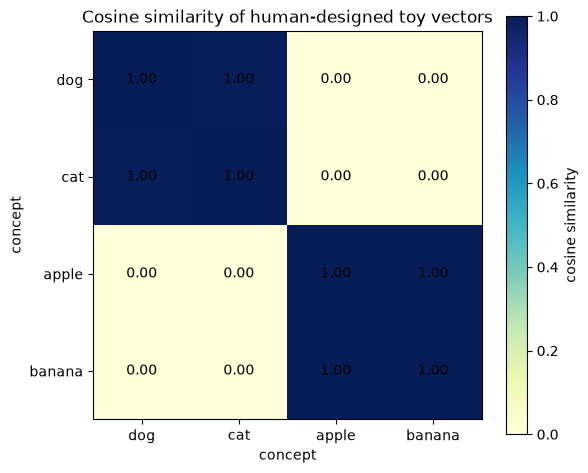

In [42]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(toy_similarity_matrix.numpy(), cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(toy_concepts)), labels=toy_concepts)
ax.set_yticks(range(len(toy_concepts)), labels=toy_concepts)
ax.set_xlabel("concept")
ax.set_ylabel("concept")
ax.set_title("Cosine similarity of human-designed toy vectors")
for row in range(len(toy_concepts)):
    for column in range(len(toy_concepts)):
        ax.text(column, row, f"{toy_similarity_matrix[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="cosine similarity")
plt.tight_layout()
plt.show()

The related pairs are close because **we designed them that way**. A language model instead learns useful distributed representations through training.

**Try it:** change one cat feature and predict how dog–cat cosine similarity changes.

## 34. PyTorch embedding layer

<code>nn.Embedding</code> stores one trainable row per token ID. This table is small enough to print completely.

In [43]:
torch.manual_seed(321)
small_vocab_size = 6
small_embedding_dim = 3
embedding_layer = nn.Embedding(small_vocab_size, small_embedding_dim)

print("Complete 6 × 3 embedding matrix:")
print(embedding_layer.weight)
print("\nShape:", tuple(embedding_layer.weight.shape))
print("rows = token IDs")
print("columns = embedding dimensions")

assert embedding_layer.weight.shape == (6, 3)

Complete 6 × 3 embedding matrix:
Parameter containing:
tensor([[-0.1302,  0.4343, -0.4491],
        [-1.0824,  2.5830, -0.3784],
        [-0.6681, -0.4460, -0.4942],
        [-1.0153,  0.9791,  1.5577],
        [-0.3924,  0.4283,  0.6376],
        [-0.5494,  0.7509,  1.7671]], requires_grad=True)

Shape: (6, 3)
rows = token IDs
columns = embedding dimensions


Row 0 belongs to token ID 0, row 1 to ID 1, and so on. These initialized values do not yet carry trained linguistic meaning.

**Try it:** change the seed and rerun. Which values change? Does the shape change?

## 35. Embedding lookup

Looking up an ID selects the matching table row.

In [44]:
small_input_ids = torch.tensor([2, 3, 5, 1])
small_embeddings = embedding_layer(small_input_ids)

for token_id, vector in zip(small_input_ids, small_embeddings):
    row_index = token_id.item()
    print(f"ID {row_index} → row {row_index} → {vector.detach()}")

lookup_matches_row = torch.allclose(
    embedding_layer(torch.tensor(3)),
    embedding_layer.weight[3],
)
print("\nID 3 lookup equals matrix row 3?", lookup_matches_row)
assert lookup_matches_row

ID 2 → row 2 → tensor([-0.6681, -0.4460, -0.4942])
ID 3 → row 3 → tensor([-1.0153,  0.9791,  1.5577])
ID 5 → row 5 → tensor([-0.5494,  0.7509,  1.7671])
ID 1 → row 1 → tensor([-1.0824,  2.5830, -0.3784])

ID 3 lookup equals matrix row 3? True


<code>nn.Embedding</code> is conceptually a trainable lookup table. It is not multiplying token IDs as numerical quantities.

**Try it:** look up ID 2 twice and compare the vectors.

## 36. Random initialization

At initialization, vectors are parameter values—not prewritten semantic definitions. Later optimization can change them.

In [45]:
print("embedding_layer.weight.requires_grad:", embedding_layer.weight.requires_grad)
assert embedding_layer.weight.requires_grad is True

embedding_layer.weight.requires_grad: True


<code>requires_grad=True</code> tells PyTorch to compute gradients for this parameter when a loss depends on it.

**Try it:** predict whether merely looking up a row—without a loss and backpropagation—changes the row.

## 37. Realistic token embedding table

We now use the GPT-2 vocabulary size and a demonstration dimension of 256. We print only shape and parameter count.

In [46]:
torch.manual_seed(456)
vocab_size = 50_257
embedding_dim = 256

token_embedding_layer = nn.Embedding(vocab_size, embedding_dim)
token_embedding_parameter_count = vocab_size * embedding_dim

print("Token embedding table shape:", token_embedding_layer.weight.shape)
print("Parameter count:", f"{token_embedding_parameter_count:,}")
print("50,257 rows = one row per possible GPT-2 token ID")
print("256 columns = one 256-dimensional vector per token")

assert token_embedding_layer.weight.shape == (50_257, 256)
assert token_embedding_parameter_count == 12_865_792

Token embedding table shape: 

torch.Size([50257, 256])
Parameter count: 12,865,792
50,257 rows = one row per possible GPT-2 token ID
256 columns = one 256-dimensional vector per token


The large table is a model parameter. Printing all 12.8 million values would obscure the lesson and waste memory in notebook output.

**Try it:** calculate the parameter count for dimension 64 before using Python.

## 38. Batch IDs → token embeddings

The batch from Section 30 contains 32 token occurrences. The lookup replaces each scalar ID with 256 features.

In [47]:
token_embeddings = token_embedding_layer(inputs)

print("inputs.shape:", inputs.shape)
print("token_embeddings.shape:", token_embeddings.shape)
print("\n8 × 4 =", 8 * 4, "token occurrences")
print("Each occurrence has", embedding_dim, "features.")
print("First token vector, first 8 values:")
print(token_embeddings[0, 0, :8])

assert inputs.shape == (8, 4)
assert token_embeddings.shape == (8, 4, 256)

inputs.shape: torch.Size([8, 4])
token_embeddings.shape: torch.Size([8, 4, 256])

8 × 4 = 32 token occurrences
Each occurrence has 256 features.
First token vector, first 8 values:
tensor([-1.1147,  0.4841, -0.5602,  0.1630,  0.5015,  1.6078,  0.0986, -0.4170],
       grad_fn=<SliceBackward0>)


<pre>8 × 4 × 256
│   │    │
│   │    └── embedding features
│   └─────── token positions per sequence
└─────────── sequences in the batch</pre>

**Try it:** predict the output shape for IDs shaped <code>[3, 10]</code> with embedding dimension 64.

## 39. Same token ID → same token embedding

An embedding lookup depends on ID, not the token's position in a sentence.

In [48]:
repeated_token_id = torch.tensor(100)
first_lookup = token_embedding_layer(repeated_token_id)
second_lookup = token_embedding_layer(repeated_token_id)

same_token_lookup = torch.equal(first_lookup, second_lookup)
print("ID 100 looked up twice; vectors identical?", same_token_lookup)
assert same_token_lookup

sentence_a = "The cat sat."
sentence_b = "Yesterday the cat slept."
sentence_a_ids = tokenizer.encode(sentence_a)
sentence_b_ids = tokenizer.encode(sentence_b)
cat_token_ids = tokenizer.encode(" cat")
assert len(cat_token_ids) == 1
cat_token_id = cat_token_ids[0]

cat_position_a = sentence_a_ids.index(cat_token_id)
cat_position_b = sentence_b_ids.index(cat_token_id)
cat_vector_a = token_embedding_layer(torch.tensor(sentence_a_ids[cat_position_a]))
cat_vector_b = token_embedding_layer(torch.tensor(sentence_b_ids[cat_position_b]))

print("\nSentence A:", sentence_a, "cat position:", cat_position_a)
print("Sentence B:", sentence_b, "cat position:", cat_position_b)
print("Same ' cat' token ID:", cat_token_id)
print("Token vectors identical before adding position?", torch.equal(cat_vector_a, cat_vector_b))

assert cat_position_a != cat_position_b
assert torch.equal(cat_vector_a, cat_vector_b)

ID 100 looked up twice; vectors identical? True



Sentence A: The cat sat. cat position: 1
Sentence B: Yesterday the cat slept. cat position: 2
Same ' cat' token ID: 3797
Token vectors identical before adding position? True


<pre>same token ID → same table row → same token embedding</pre>

This remains true before position information is added, regardless of sequence position.

**Try it:** create a third sentence containing lowercase <code> cat</code> and locate the same ID.

# Phase E — Add position information

Create positional vectors and add them to token embeddings so order is available to the model.

## 40. Why position information is needed

<pre>dog bites man        man bites dog

the cat sat on the mat
on the mat the cat sat</pre>

The collection of token identities can be similar while order changes roles and meaning. Token embeddings alone do not explicitly identify sequence position.

**Try it:** construct another pair of short sentences whose meaning changes when two tokens swap.

## 41. Absolute positional embeddings

Absolute position answers: **“At which exact position inside this context window am I?”** With context length 4, we need <code>P0</code> through <code>P3</code>.

In [49]:
torch.manual_seed(789)
context_length = 4
embedding_dim = 256
position_embedding_layer = nn.Embedding(context_length, embedding_dim)

print("Position embedding table shape:", position_embedding_layer.weight.shape)
print("Rows: P0, P1, P2, P3")
print("One vector for each possible position inside the context window.")

assert position_embedding_layer.weight.shape == (4, 256)

Position embedding table shape: torch.Size([4, 256])
Rows: P0, P1, P2, P3
One vector for each possible position inside the context window.


These learned absolute vectors are model parameters, usually initialized before training and optimized with the rest of the model.

**Try it:** if context length becomes 8, predict the number of position rows.

## 42. Token table vs. position table

They share the same column dimension because their rows will be added, but they are indexed by entirely different quantities.

In [50]:
print("TOKEN EMBEDDING TABLE")
print("  shape      = 50,257 × 256")
print("  indexed by = token ID")
print("\nPOSITION EMBEDDING TABLE")
print("  shape      = 4 × 256")
print("  indexed by = sequence position")

TOKEN EMBEDDING TABLE
  shape      = 50,257 × 256
  indexed by = token ID

POSITION EMBEDDING TABLE
  shape      = 4 × 256
  indexed by = sequence position


> The vocabulary does **not** contain one positional vector for every token. Token and positional embeddings are separate tables.

**Try it:** which table row is selected by token ID 100? Which table row is selected at sequence position 2?

## 43. Generate position IDs

<code>torch.arange(context_length)</code> creates the within-window positions directly.

In [51]:
position_ids = torch.arange(context_length)
pos_embeddings = position_embedding_layer(position_ids)

print("Position IDs:", position_ids)
print("Position embeddings shape:", pos_embeddings.shape)
print("\nFirst 5 values of each position vector:")
for position in range(context_length):
    print(f"P{position}:", pos_embeddings[position, :5].detach())

assert torch.equal(position_ids, torch.tensor([0, 1, 2, 3]))
assert pos_embeddings.shape == (4, 256)

Position IDs: tensor([0, 1, 2, 3])
Position embeddings shape: torch.Size([4, 256])

First 5 values of each position vector:
P0: tensor([-0.4801, -0.8470, -0.3716,  0.8741, -0.1331])
P1: tensor([ 0.1077,  1.0544,  1.2508,  0.5623, -1.5081])
P2: tensor([ 1.6099, -0.4825, -1.9951,  0.4080,  0.2441])
P3: tensor([-0.1033, -0.6885,  0.0094,  0.3029, -0.7825])


The position IDs select exactly four rows. We display five values per row rather than all 256.

**Try it:** predict the last position ID for context length 8.

## 44. The same position vectors are reused across the batch

<pre>Sequence 1: token0 + P0   token1 + P1   token2 + P2   token3 + P3
Sequence 2: token0 + P0   token1 + P1   token2 + P2   token3 + P3
    ⋮
Sequence 8: token0 + P0   token1 + P1   token2 + P2   token3 + P3</pre>

Position 0 means position 0 regardless of which batch item is processed. The model therefore stores <code>4 × 256</code>, not eight independent copies shaped <code>8 × 4 × 256</code>.

**Try it:** identify which positional row is added to <code>inputs[6, 3]</code>.

## 45. Broadcasting with readable numbers

Before adding 256-dimensional vectors, inspect a complete <code>[2, 3, 2]</code> example.

In [52]:
token_embeddings_small = torch.tensor([
    [[1., 10.], [2., 20.], [3., 30.]],
    [[4., 40.], [5., 50.], [6., 60.]],
])
position_embeddings_small = torch.tensor([
    [0.1, 0.2],   # P0
    [1.0, 2.0],   # P1
    [10.0, 20.0], # P2
])

input_embeddings_small = token_embeddings_small + position_embeddings_small

print("Token embeddings [2, 3, 2]:\n", token_embeddings_small)
print("\nPosition embeddings [3, 2]:\n", position_embeddings_small)
print("\nResult [2, 3, 2]:\n", input_embeddings_small)

for batch_index in range(2):
    for position in range(3):
        expected = token_embeddings_small[batch_index, position] + position_embeddings_small[position]
        assert torch.equal(input_embeddings_small[batch_index, position], expected)

print("\nEvery sequence reused P0, P1, and P2: checks passed.")

Token embeddings [2, 3, 2]:
 tensor([[[ 1., 10.],
         [ 2., 20.],
         [ 3., 30.]],

        [[ 4., 40.],
         [ 5., 50.],
         [ 6., 60.]]])

Position embeddings [3, 2]:
 tensor([[ 0.1000,  0.2000],
        [ 1.0000,  2.0000],
        [10.0000, 20.0000]])

Result [2, 3, 2]:
 tensor([[[ 1.1000, 10.2000],
         [ 3.0000, 22.0000],
         [13.0000, 50.0000]],

        [[ 4.1000, 40.2000],
         [ 6.0000, 52.0000],
         [16.0000, 80.0000]]])

Every sequence reused P0, P1, and P2: checks passed.


<pre>[2, 3, 2]
+   [3, 2]
──────────
[2, 3, 2]</pre>

PyTorch aligns trailing dimensions and behaves as if the <code>[3, 2]</code> position matrix were reused across both batch items. It need not manually store those copies.

**Try it:** calculate the result at batch 1, position 2 by hand.

## 46. Real broadcasting

Now the same rule combines <code>[8, 4, 256]</code> token embeddings with <code>[4, 256]</code> position embeddings.

In [53]:
input_embeddings = token_embeddings + pos_embeddings

print("token_embeddings.shape:", token_embeddings.shape)
print("pos_embeddings.shape:  ", pos_embeddings.shape)
print("input_embeddings.shape:", input_embeddings.shape)

batch_0_p2_check = torch.allclose(
    input_embeddings[0, 2],
    token_embeddings[0, 2] + pos_embeddings[2],
)
batch_5_p2_check = torch.allclose(
    input_embeddings[5, 2],
    token_embeddings[5, 2] + pos_embeddings[2],
)

print("\nBatch item 0 used P2 at position 2?", batch_0_p2_check)
print("Batch item 5 used the SAME P2 at position 2?", batch_5_p2_check)

assert input_embeddings.shape == (8, 4, 256)
assert batch_0_p2_check and batch_5_p2_check

token_embeddings.shape: torch.Size([8, 4, 256])
pos_embeddings.shape:   torch.Size([4, 256])
input_embeddings.shape: torch.Size([8, 4, 256])

Batch item 0 used P2 at position 2? True
Batch item 5 used the SAME P2 at position 2? True


Both different sequences use the same learned <code>P2</code> at their third token position.

**Try it:** perform the same check for batch item 7 at position 0.

## 47. Same token at two positions

Let <code>C</code> be one fixed token vector. Adding <code>P0</code> and <code>P3</code> creates two different initial input representations.

In [54]:
C = token_embedding_layer(torch.tensor(cat_token_id))
C_plus_P0 = C + pos_embeddings[0]
C_plus_P3 = C + pos_embeddings[3]

print("C, first 8 values:     ", C[:8])
print("P0, first 8 values:    ", pos_embeddings[0, :8])
print("P3, first 8 values:    ", pos_embeddings[3, :8])
print("C + P0, first 8 values:", C_plus_P0[:8])
print("C + P3, first 8 values:", C_plus_P3[:8])

same_token_different_position = not torch.equal(C_plus_P0, C_plus_P3)
print("\nFinal input representations differ?", same_token_different_position)
assert same_token_different_position

C, first 8 values:      tensor([ 0.5050,  1.1085, -0.6852,  0.1702, -0.4072, -0.8504,  0.6914,  1.1236],
       grad_fn=<SliceBackward0>)
P0, first 8 values:     tensor([-0.4801, -0.8470, -0.3716,  0.8741, -0.1331, -0.7501, -0.9419,  0.4189],
       grad_fn=<SliceBackward0>)
P3, first 8 values:     tensor([-0.1033, -0.6885,  0.0094,  0.3029, -0.7825,  0.3120,  0.2418,  1.0521],
       grad_fn=<SliceBackward0>)
C + P0, first 8 values: tensor([ 0.0248,  0.2615, -1.0569,  1.0444, -0.5403, -1.6005, -0.2505,  1.5425],
       grad_fn=<SliceBackward0>)
C + P3, first 8 values: tensor([ 0.4017,  0.4200, -0.6759,  0.4731, -1.1896, -0.5384,  0.9332,  2.1757],
       grad_fn=<SliceBackward0>)

Final input representations differ? True


<pre>same token + different position = different initial input representation</pre>

**Try it:** compute the Euclidean distance between <code>C_plus_P0</code> and <code>C_plus_P3</code>.

## 48. Important position clarification

> <code>P2</code> does **not** mean “how the word cat behaves at position 2.”

<code>P2</code> represents information associated with **position 2**.

<pre>cat at position 2   → C + P2
dog at position 2   → D + P2
apple at position 2 → A + P2</pre>

The same positional vector is reused. Later Transformer processing uses token identity, position, and surrounding context to determine contextual behavior.

**Try it:** explain why there is no separate <code>cat-at-P2</code> row in either table.

## 49. Relative position concept

Relative position compares pairs. For reference position <code>i</code> and other position <code>j</code>, we calculate <code>j − i</code>. This is conceptual; we do not implement relative attention.

relative[i, j] = j - i
[[ 0  1  2  3]
 [-1  0  1  2]
 [-2 -1  0  1]
 [-3 -2 -1  0]]


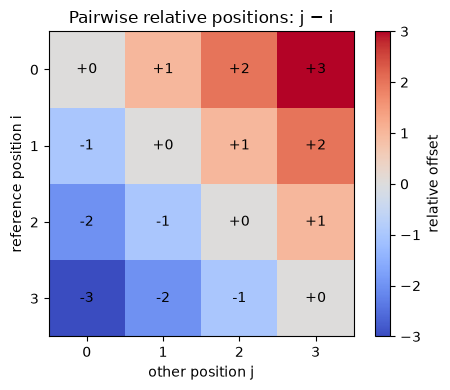

In [55]:
relative_positions = np.arange(4)
relative_matrix = relative_positions[None, :] - relative_positions[:, None]

print("relative[i, j] = j - i")
print(relative_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(relative_matrix, cmap="coolwarm", vmin=-3, vmax=3)
for i_position in range(4):
    for j_position in range(4):
        ax.text(
            j_position,
            i_position,
            f"{relative_matrix[i_position, j_position]:+d}",
            ha="center",
            va="center",
            color="black",
        )
ax.set_xticks(range(4), labels=range(4))
ax.set_yticks(range(4), labels=range(4))
ax.set_xlabel("other position j")
ax.set_ylabel("reference position i")
ax.set_title("Pairwise relative positions: j − i")
fig.colorbar(image, ax=ax, label="relative offset")
plt.tight_layout()
plt.show()

assert relative_matrix[0, 3] == 3
assert relative_matrix[3, 0] == -3

<pre>Absolute: “I am at position 7.”
Relative: “You are 2 positions after me.”</pre>

There is not one permanent reference token for the sentence. Each row changes the reference <code>i</code>, so relative position is pairwise.

**Try it:** which cell represents “position 1 is two places before position 3”?

## 50. Absolute vs. relative summary

| Absolute position | Relative position |
|---|---|
| Exact sequence location | Distance/relation between positions |
| Example: “at position 7” | Example: “2 positions after me” |
| One location considered directly | A pair of locations considered together |

This is a conceptual comparison only. We do not implement full Transformer variants.

**Try it:** describe position 5 absolutely and relative to position 2.

## 51. Final input embeddings

We now have the exact tensor that would be sent toward a Transformer.

In [56]:
print("Input token IDs:       ", inputs.shape)
print("Token embeddings:      ", token_embeddings.shape)
print("Position embeddings:   ", pos_embeddings.shape)
print("Final input embeddings:", input_embeddings.shape)
print("\nFirst final vector, first 8 values:")
print(input_embeddings[0, 0, :8])

assert inputs.shape == (8, 4)
assert token_embeddings.shape == (8, 4, 256)
assert pos_embeddings.shape == (4, 256)
assert input_embeddings.shape == (8, 4, 256)

Input token IDs:        torch.Size([8, 4])
Token embeddings:       torch.Size([8, 4, 256])
Position embeddings:    torch.Size([4, 256])
Final input embeddings: torch.Size([8, 4, 256])

First final vector, first 8 values:


tensor([-1.5949, -0.3630, -0.9318,  1.0371,  0.3684,  0.8577, -0.8432,  0.0019],
       grad_fn=<SliceBackward0>)


<pre>TOKEN EMBEDDING
“What token am I?”

POSITION EMBEDDING
“Where am I?”

FINAL INPUT EMBEDDING
initial combination of token + position information</pre>

**Try it:** state which dimension corresponds to feature values in <code>[8, 4, 256]</code>.

## 52. Prove token and position embeddings are trainable

This very small next-token model contains no Transformer:

<pre>token IDs
    ↓
token embedding + position embedding
    ↓
linear output layer
    ↓
vocabulary logits → cross-entropy loss</pre>

In [57]:
torch.manual_seed(900)
toy_vocab_size = 7
toy_embedding_dim = 4
toy_context_length = 4

toy_token_embedding = nn.Embedding(toy_vocab_size, toy_embedding_dim)
toy_position_embedding = nn.Embedding(toy_context_length, toy_embedding_dim)
toy_output_layer = nn.Linear(toy_embedding_dim, toy_vocab_size)

toy_inputs = torch.tensor([[0, 1, 2, 3]])
toy_targets = torch.tensor([[1, 2, 3, 4]])
toy_position_ids = torch.arange(toy_context_length)

used_token_id = 0
used_position_id = 0
toy_token_before = toy_token_embedding.weight[used_token_id].detach().clone()
toy_position_before = toy_position_embedding.weight[used_position_id].detach().clone()

optimizer = torch.optim.SGD(
    list(toy_token_embedding.parameters())
    + list(toy_position_embedding.parameters())
    + list(toy_output_layer.parameters()),
    lr=0.1,
)

print("Used token row before:   ", toy_token_before)
print("Used position row before:", toy_position_before)

Used token row before:    tensor([ 2.0870,  0.8512,  0.6453, -1.5408])
Used position row before: tensor([-0.5798, -0.1508,  0.8274, -0.9458])


In [58]:
optimizer.zero_grad()

toy_token_vectors = toy_token_embedding(toy_inputs)
toy_position_vectors = toy_position_embedding(toy_position_ids)
toy_combined_vectors = toy_token_vectors + toy_position_vectors
toy_logits = toy_output_layer(toy_combined_vectors)

toy_loss = F.cross_entropy(
    toy_logits.reshape(-1, toy_vocab_size),
    toy_targets.reshape(-1),
)
toy_loss.backward()

toy_token_gradient = toy_token_embedding.weight.grad[used_token_id].detach().clone()
toy_position_gradient = toy_position_embedding.weight.grad[used_position_id].detach().clone()
token_gradient_nonzero = bool(torch.any(toy_token_gradient != 0))
position_gradient_nonzero = bool(torch.any(toy_position_gradient != 0))

print("Loss:", toy_loss.item())
print("Token embedding gradient:   ", toy_token_gradient)
print("Position embedding gradient:", toy_position_gradient)
print("Token gradient nonzero?", token_gradient_nonzero)
print("Position gradient nonzero?", position_gradient_nonzero)

assert token_gradient_nonzero
assert position_gradient_nonzero
optimizer.step()

Loss: 2.0300498008728027
Token embedding gradient:    tensor([ 0.0916, -0.0266,  0.0402, -0.0072])
Position embedding gradient: tensor([ 0.0916, -0.0266,  0.0402, -0.0072])
Token gradient nonzero? True
Position gradient nonzero? True


In [59]:
toy_token_after = toy_token_embedding.weight[used_token_id].detach().clone()
toy_position_after = toy_position_embedding.weight[used_position_id].detach().clone()
toy_token_changed = not torch.equal(toy_token_before, toy_token_after)
toy_position_changed = not torch.equal(toy_position_before, toy_position_after)

print("TOKEN EMBEDDING")
print("before:  ", toy_token_before)
print("after:   ", toy_token_after)
print("changed?", toy_token_changed)

print("\nPOSITION EMBEDDING")
print("before:  ", toy_position_before)
print("after:   ", toy_position_after)
print("changed?", toy_position_changed)

assert toy_token_changed
assert toy_position_changed

TOKEN EMBEDDING
before:   tensor([ 2.0870,  0.8512,  0.6453, -1.5408])
after:    tensor([ 2.0778,  0.8538,  0.6412, -1.5401])
changed? True

POSITION EMBEDDING
before:   tensor([-0.5798, -0.1508,  0.8274, -0.9458])
after:    tensor([-0.5890, -0.1481,  0.8234, -0.9450])
changed? True


There is no separate “position embedding loss.” The same next-token loss backpropagates through the entire computation graph into token rows, position rows, and later model parameters.

**Try it:** which unused token rows would receive zero gradient in this one-example step?

# Phase F — Assemble the full pipeline

Connect tokenization, batching, token lookup, and position lookup into one Transformer-ready tensor.

## 53. Full end-to-end pipeline run

This clean run starts again from the custom text and moves through every operational stage. We print only useful samples and shapes.

In [60]:
final_token_ids = tokenizer.encode(raw_text)
final_first_pieces = [
    tokenizer.decode_single_token_bytes(token_id).decode("utf-8", errors="replace")
    for token_id in final_token_ids[:8]
]

final_dataset = GPTDatasetV1(
    raw_text,
    tokenizer,
    max_length=4,
    stride=4,
)
final_dataloader = DataLoader(
    final_dataset,
    batch_size=8,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)
final_inputs, final_targets = next(iter(final_dataloader))

final_token_embeddings = token_embedding_layer(final_inputs)
final_position_ids = torch.arange(4)
final_position_embeddings = position_embedding_layer(final_position_ids)
final_input_embeddings = final_token_embeddings + final_position_embeddings

print("RAW TEXT sample:", repr(raw_text[:80]))
print("↓ GPT-2 BPE tokens (first 8):", final_first_pieces)
print("↓ token IDs (first 8):", final_token_ids[:8])
print("↓ first X pair:", final_inputs[0].tolist())
print("  first Y pair:", final_targets[0].tolist())
print("↓ Dataset windows:", len(final_dataset))
print("↓ DataLoader inputs:", final_inputs.shape)
print("  DataLoader targets:", final_targets.shape)
print("↓ token embedding lookup:", final_token_embeddings.shape)
print("+ position embeddings:", final_position_embeddings.shape)
print("↓ broadcast/add")
print("FINAL INPUT EMBEDDINGS:", final_input_embeddings.shape)

assert final_inputs.shape == (8, 4)
assert final_targets.shape == (8, 4)
assert final_token_embeddings.shape == (8, 4, 256)
assert final_position_embeddings.shape == (4, 256)
assert final_input_embeddings.shape == (8, 4, 256)

RAW TEXT sample: 'The small language-model laboratory opened early on Monday. A boy carried an old'
↓ GPT-2 BPE tokens (first 8): ['The', ' small', ' language', '-', 'model', ' laboratory', ' opened', ' early']
↓ token IDs (first 8): [464, 1402, 3303, 12, 19849, 14010, 4721, 1903]
↓ first X pair: [464, 1402, 3303, 12]
  first Y pair: [1402, 3303, 12, 19849]
↓ Dataset windows: 97
↓ DataLoader inputs: torch.Size([8, 4])
  DataLoader targets: torch.Size([8, 4])
↓ token embedding lookup: torch.Size([8, 4, 256])
+ position embeddings: torch.Size([4, 256])
↓ broadcast/add
FINAL INPUT EMBEDDINGS: torch.Size([8, 4, 256])


Nothing was skipped: raw characters became BPE IDs, shifted Dataset windows, a batched tensor, token vectors, and finally token-plus-position vectors.

**Try it:** point to the exact line where scalar IDs become 256-number vectors.

## 54. Shape ledger

Final symbols: <code>B = 8</code>, <code>T = 4</code>, <code>V = 50,257</code>, <code>D = 256</code>.

| Stage | Symbolic shape | Final shape | Meaning |
|---|---|---|---|
| Token IDs | <code>[B, T]</code> | <code>[8, 4]</code> | batch sequences × positions |
| Token embedding matrix | <code>[V, D]</code> | <code>[50,257, 256]</code> | vocabulary × embedding dimension |
| Token embeddings | <code>[B, T, D]</code> | <code>[8, 4, 256]</code> | vector for every token occurrence |
| Position embedding matrix | <code>[T, D]</code> | <code>[4, 256]</code> | vector for every within-window position |
| Final input embeddings | <code>[B, T, D]</code> | <code>[8, 4, 256]</code> | token + position representation |

**Try it:** rewrite the ledger for <code>B=2</code>, <code>T=8</code>, and <code>D=64</code>.

## 55. Concept checkpoints

These assertions gather the notebook's main executable claims in one place.

In [61]:
assert tokenizer.decode(tokenizer.encode(gpt2_text)) == gpt2_text
assert inputs.shape == (8, 4)
assert targets.shape == (8, 4)
assert token_embeddings.shape == (8, 4, 256)
assert pos_embeddings.shape == (4, 256)
assert input_embeddings.shape == (8, 4, 256)
assert torch.allclose(
    input_embeddings[0, 2],
    token_embeddings[0, 2] + pos_embeddings[2],
)
assert same_token_lookup
assert torch.equal(cat_vector_a, cat_vector_b)
assert same_token_different_position
assert token_gradient_nonzero
assert position_gradient_nonzero
assert toy_token_changed
assert toy_position_changed

print("✓ decode(encode(text)) round trip")
print("✓ inputs and targets are [8, 4]")
print("✓ token embeddings are [8, 4, 256]")
print("✓ position embeddings are [4, 256]")
print("✓ final input embeddings are [8, 4, 256]")
print("✓ broadcasting equation at [0, 2]")
print("✓ same token ID gives the same token embedding")
print("✓ same token plus different position gives a different final vector")
print("✓ token and position embeddings both received gradients and changed")

✓ decode(encode(text)) round trip
✓ inputs and targets are [8, 4]
✓ token embeddings are [8, 4, 256]
✓ position embeddings are [4, 256]
✓ final input embeddings are [8, 4, 256]
✓ broadcasting equation at [0, 2]
✓ same token ID gives the same token embedding
✓ same token plus different position gives a different final vector
✓ token and position embeddings both received gradients and changed


Assertions turn explanations into falsifiable checks. If an experiment violates a shape or equality assumption, execution stops at the relevant claim.

**Try it:** deliberately change one expected shape, observe the assertion, then restore it.

## 56. Final visual pipeline

<pre>RAW TEXT
   ↓
BPE TOKENIZER
   ↓
TOKENS
   ↓
TOKEN IDs
   ↓
SLIDING WINDOWS
   ↓
INPUT / TARGET PAIRS
   ↓
DATASET
   ↓
DATALOADER
   ↓
BATCH [B, T]
   ↓
┌──────────────────────────┐
│ TOKEN EMBEDDING LOOKUP   │
│ token ID → vector        │
│ [B, T] → [B, T, D]       │
└──────────────────────────┘
              +
┌──────────────────────────┐
│ POSITION EMBEDDING       │
│ position → vector        │
│ [T] → [T, D]             │
└──────────────────────────┘
              ↓
          BROADCAST
              ↓
FINAL INPUT EMBEDDINGS
          [B, T, D]
              ↓
      TRANSFORMER
       (next topic)</pre>

# Final checks

Use the following assertions and questions to verify both the pipeline and your understanding.

## 57. Final theory quiz

Answer these before opening the answer section.

1. What is tokenization?
2. Why is splitting only on whitespace insufficient?
3. Why might punctuation be separate tokens?
4. What is a vocabulary?
5. What is a token ID?
6. Why is token ID magnitude meaningless?
7. What does <code>encode()</code> do?
8. What does <code>decode()</code> do?
9. What is OOV?
10. What does <code>&lt;|unk|&gt;</code> do?
11. What does <code>&lt;|endoftext|&gt;</code> do?
12. How do word and character tokenizers differ?
13. Why use subword tokenization?
14. What does BPE repeatedly merge?
15. How can byte-level BPE encode unseen-looking words?
16. What is context length?
17. What is stride?
18. Why are targets shifted by one token?
19. How can one sequence contain multiple next-token targets?
20. What is the difference between a Dataset and a DataLoader?
21. What is batch size?
22. Why are token IDs alone insufficient model inputs?
23. What is an embedding lookup table?
24. Why is the token embedding matrix <code>V × D</code>?
25. Why is the positional embedding matrix <code>T × D</code>?
26. Why must token and positional embedding dimensions match for addition?
27. Why does <code>[8,4,256] + [4,256]</code> work?
28. What is broadcasting?
29. What is absolute position?
30. What is relative position?
31. Are learned token embeddings trainable?
32. Are learned positional embeddings trainable?
33. Does <code>P2</code> specifically describe “cat at position 2”?
34. What final tensor is fed toward the Transformer?

<details>
<summary><strong>QUIZ ANSWERS — CHECK ONLY AFTER ATTEMPTING</strong></summary>

1. Converting text into a sequence of tokenizer-defined units.
2. Punctuation remains attached and whitespace rules alone cannot express all desired boundaries.
3. It can carry structure and meaning and may need its own reusable representation.
4. A mapping between unique tokens and IDs.
5. An integer identifier for one vocabulary entry.
6. It is a row label, not a semantic measurement.
7. It maps text/tokens to token IDs.
8. It maps token IDs back to text.
9. Out Of Vocabulary: a token absent from a fixed vocabulary.
10. It replaces an unrecognized token in tokenizers that use an unknown marker.
11. It marks a boundary between documents or text segments.
12. Word tokenizers make shorter sequences but large/OOV-prone vocabularies; character tokenizers use small vocabularies but longer sequences.
13. To reuse pieces between word and character granularity and represent new-looking words.
14. The most frequent adjacent token/piece pair under its training procedure.
15. It decomposes text into known smaller byte-level pieces.
16. The number of token positions in one training window.
17. How far the next window's start moves.
18. Each input position should target the following stream token.
19. Every input position has its own following-token target.
20. A Dataset defines one example; a DataLoader batches, shuffles, and loads examples.
21. The number of sequences processed together.
22. IDs identify tokens but contain no trainable distributed representation or explicit position.
23. A trainable matrix whose row is selected by an ID.
24. One row for each of <code>V</code> tokens and <code>D</code> features per row.
25. One row for each of <code>T</code> positions and <code>D</code> features per row.
26. Element-wise addition needs matching feature counts.
27. PyTorch reuses the <code>[4,256]</code> matrix across the batch dimension.
28. Implicitly applying a compatible smaller tensor across missing/larger dimensions without manual copies.
29. An exact sequence location.
30. A pairwise distance or relation between positions.
31. Yes.
32. Yes, when the model uses learned positional embeddings.
33. No. <code>P2</code> represents position 2 and is reused for every token there.
34. The final input embeddings <code>[B,T,D]</code>, equal to token embeddings plus positional embeddings.

</details>

## 58. Final coding challenges

1. Change the regex punctuation rules and observe the produced tokens.
2. Add an unknown word and compare V1 with V2.
3. Change the BPE merge count and inspect learned pieces.
4. Change context length from 4 to 8.
5. Change stride from 4 to 1 and count Dataset samples.
6. Change batch size and predict the first batch shape before running.
7. Change embedding dimension from 256 to 64 and predict downstream shapes.
8. Put the same token at two positions and prove its token vector stays the same while its final vectors differ.

The next eight cells are compact reference solutions. Try your own version first.

In [62]:
# Solution 1 — add slash as a separately captured punctuation token
challenge_pattern = r"([,.!?;:/]|\s+)"
challenge_text_1 = "paths/to;tokens!"
challenge_tokens_1 = [
    item for item in re.split(challenge_pattern, challenge_text_1)
    if item and item.strip()
]
print(challenge_tokens_1)

['paths', '/', 'to', ';', 'tokens', '!']


In [63]:
# Solution 2 — V1 fails; V2 produces the unknown ID
challenge_unknown = "hyperbananaquantum"
try:
    tokenizer_v1.encode(challenge_unknown)
except KeyError:
    print("V1: OOV KeyError (caught safely)")

challenge_v2_ids = tokenizer_v2.encode(challenge_unknown)
print("V2 IDs:", challenge_v2_ids)
print("V2 decoded:", tokenizer_v2.decode(challenge_v2_ids))
assert challenge_v2_ids == [vocab_with_special["<|unk|>"]]

V1: OOV KeyError (caught safely)
V2 IDs: [192]
V2 decoded: <|unk|>


In [64]:
# Solution 3 — compare final pieces after two and eight calculated merges
def pieces_after_n_merges(merge_count):
    vocabulary = dict(initial_bpe_vocab)
    for _ in range(merge_count):
        counts_for_step = count_adjacent_pairs(vocabulary)
        if not counts_for_step:
            break
        pair_for_step, _ = max(counts_for_step.items(), key=lambda item: (item[1], item[0]))
        vocabulary = merge_adjacent_pair(pair_for_step, vocabulary)
    return sorted({piece for symbols in vocabulary for piece in symbols})

print("Pieces after 2 merges:", pieces_after_n_merges(2))
print("Pieces after 8 merges:", pieces_after_n_merges(8))

Pieces after 2 merges: ['</w>', 'd', 'e', 'f', 'i', 'l', 'n', 'o', 'r', 'st</w>', 'w']
Pieces after 8 merges: ['</w>', 'e', 'est</w>', 'finest</w>', 'l', 'o', 'old', 'r', 'w']


In [65]:
# Solution 4 — use context length 8
challenge_dataset_length_8 = GPTDatasetV1(raw_text, tokenizer, max_length=8, stride=8)
challenge_x8, challenge_y8 = challenge_dataset_length_8[0]
print("X shape:", challenge_x8.shape)
print("Y shape:", challenge_y8.shape)
assert challenge_x8.shape == challenge_y8.shape == (8,)

X shape: torch.Size([8])
Y shape: torch.Size([8])


In [66]:
# Solution 5 — smaller stride produces more windows
challenge_dataset_stride_4 = GPTDatasetV1(raw_text, tokenizer, max_length=4, stride=4)
challenge_dataset_stride_1 = GPTDatasetV1(raw_text, tokenizer, max_length=4, stride=1)
print("stride 4 examples:", len(challenge_dataset_stride_4))
print("stride 1 examples:", len(challenge_dataset_stride_1))
assert len(challenge_dataset_stride_1) > len(challenge_dataset_stride_4)

stride 4 examples: 97
stride 1 examples: 385


In [67]:
# Solution 6 — predict [3, 4], then verify
challenge_loader_batch_3 = DataLoader(dataset, batch_size=3, shuffle=False, num_workers=0)
challenge_inputs_3, challenge_targets_3 = next(iter(challenge_loader_batch_3))
print("Predicted input shape: [3, 4]")
print("Actual input shape:   ", list(challenge_inputs_3.shape))
print("Actual target shape:  ", list(challenge_targets_3.shape))
assert challenge_inputs_3.shape == challenge_targets_3.shape == (3, 4)

Predicted input shape: [3, 4]
Actual input shape:    [3, 4]
Actual target shape:   [3, 4]


In [68]:
# Solution 7 — dimension 64 changes D, not B or T
challenge_token_embedding_64 = nn.Embedding(50_257, 64)
challenge_position_embedding_64 = nn.Embedding(4, 64)
challenge_token_vectors_64 = challenge_token_embedding_64(inputs)
challenge_position_vectors_64 = challenge_position_embedding_64(torch.arange(4))
challenge_final_vectors_64 = challenge_token_vectors_64 + challenge_position_vectors_64

print("Token table:", tuple(challenge_token_embedding_64.weight.shape))
print("Token vectors:", tuple(challenge_token_vectors_64.shape))
print("Position vectors:", tuple(challenge_position_vectors_64.shape))
print("Final vectors:", tuple(challenge_final_vectors_64.shape))
assert challenge_final_vectors_64.shape == (8, 4, 64)

Token table: (50257, 64)
Token vectors: (8, 4, 64)
Position vectors: (4, 64)
Final vectors: (8, 4, 64)


In [69]:
# Solution 8 — same lookup, different added position rows
challenge_same_token_a = token_embedding_layer(torch.tensor(cat_token_id))
challenge_same_token_b = token_embedding_layer(torch.tensor(cat_token_id))
challenge_final_at_0 = challenge_same_token_a + pos_embeddings[0]
challenge_final_at_3 = challenge_same_token_b + pos_embeddings[3]

print("Token vectors same?", torch.equal(challenge_same_token_a, challenge_same_token_b))
print("Final vectors same?", torch.equal(challenge_final_at_0, challenge_final_at_3))
assert torch.equal(challenge_same_token_a, challenge_same_token_b)
assert not torch.equal(challenge_final_at_0, challenge_final_at_3)

Token vectors same? True
Final vectors same? False


## 59. Final “Can I explain this?” check

I can explain:

- [ ] raw text vs. tokens
- [ ] word tokenization
- [ ] character tokenization
- [ ] subword tokenization
- [ ] BPE
- [ ] vocabulary
- [ ] token IDs
- [ ] encode/decode
- [ ] OOV
- [ ] unknown tokens
- [ ] end-of-text token
- [ ] context length
- [ ] stride
- [ ] sliding windows
- [ ] input-target shifting
- [ ] multiple next-token targets
- [ ] Dataset
- [ ] DataLoader
- [ ] batch size
- [ ] token embeddings
- [ ] embedding lookup
- [ ] embedding matrix dimensions
- [ ] positional embeddings
- [ ] absolute position
- [ ] relative position
- [ ] broadcasting
- [ ] final input embeddings
- [ ] why embeddings are trainable
- [ ] how next-token loss can update them

> **If I understand every step above, I understand how raw text is transformed into the numerical input that can be fed into a GPT-style Transformer.**

### Final compact demonstration

This last executable cell repeats the essential samples and shapes. It ends before Transformer architecture.

In [70]:
print("Raw text →", repr(raw_text[:60]) + "...")
print("First few BPE tokens →", final_first_pieces)
print("First few token IDs →", final_token_ids[:8])
print("X/Y pair →", final_inputs[0].tolist(), "/", final_targets[0].tolist())
print("Batch shapes →", list(final_inputs.shape), list(final_targets.shape))
print("Token embedding shape →", list(final_token_embeddings.shape))
print("Position embedding shape →", list(final_position_embeddings.shape))
print("Final input embedding shape →", list(final_input_embeddings.shape))
print("\n[8, 4, 256]")
print("READY TO ENTER THE TRANSFORMER")

Raw text → 'The small language-model laboratory opened early on Monday. '...
First few BPE tokens → ['The', ' small', ' language', '-', 'model', ' laboratory', ' opened', ' early']
First few token IDs → [464, 1402, 3303, 12, 19849, 14010, 4721, 1903]
X/Y pair → [464, 1402, 3303, 12] / [1402, 3303, 12, 19849]
Batch shapes → [8, 4] [8, 4]
Token embedding shape → [8, 4, 256]
Position embedding shape → [4, 256]
Final input embedding shape → [8, 4, 256]

[8, 4, 256]
READY TO ENTER THE TRANSFORMER
